# Vector Field Navigation Notebook

It allows you to:
* Define your vector field of your choice
* Define your robot cluster
* Define your favorite primitives (action policy to achieve intended goal)
* Watch your robots use primitives (action policy's) to navigate the environment

Update 11/27/2023
* Refactored into agent, action, environment model.
* Define the class cluster with relevant methods.
* Identified way to pass less info to primitives.
* Started rewriting the primitives to be centroid movers.


Next steps: 11 hours of work.
* Define the primitives to only move the robot centroid.
* Redefine the Main Algorithm Execution
* Find a sexier way to define the environment.
* Test to make sure the primitives actually do what I think they do.
* Show a "method" which uses some theoretical 3pt filter method.
* Show what a 4 robot cluster would do without breaking the environment.
* Add noise to the readings.
* Add noise to the enviroment.
* Show an implementation of the "momentum"
* Create a diagram showcasing the control architecture.
* Look into fast_finder_aligned. It has an AND condition that repeats itself.

Some thoughts:

These are designed to work well in smooth fields. However, we do need to introduce both the concept of noise in the field, and in sensor noise.

To compensate for the noise, we may need something in this form:

V(system) = V(system) + alpha*( f(environment) - V(system) ) 

## 1. Define the Agent - The Robot Cluster Class

Currently, we are using a angle/distance way of describing the robot positions relative the robot cluster centroid. This will need to get replaced with a cluster-control way of describing it.

In [ ]:
# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt


class RobotCluster:

    def __init__(self):
        self.reset()

    def reset(self):
        self.cluster_centre = [2, 1.6]
        self.robot_1_offset = [0, 0.5]
        self.robot_2_offset = [0.3, -0.3]
        self.robot_3_offset = [-0.4, -0.32]
        self.step_size = 0.1                # I am not sure if this is the best place for this for now.
        self.angle = 0 

    def pose(self):
        pos1 = [self.cluster_centre[0] + self.robot_1_offset[0], self.cluster_centre[1] + self.robot_1_offset[1]]
        pos2 = [self.cluster_centre[0] + self.robot_2_offset[0], self.cluster_centre[1] + self.robot_2_offset[1]]
        pos3 = [self.cluster_centre[0] + self.robot_3_offset[0], self.cluster_centre[1] + self.robot_3_offset[1]]
        return pos1, pos2, pos3

    def plot(self):
        pos1, pos2, pos3 = self.pose()
        plt.scatter(pos1[0], pos1[1], marker='o', color='blue')
        plt.scatter(pos2[0], pos2[1], marker='o', color='yellow')
        plt.scatter(pos3[0], pos3[1], marker='o', color='green')
        #plt.show()
        
    def bot_readings(self):
        readings = []
        for pos in self.pose():
            readings.append(position_readings(pos[0], pos[1]))
        return readings
    
    def bot_compvec(self):
        comp_vectors = []
        for u, v in self.bot_readings():
            comp_vectors.append(composite_vector(u, v))
        return comp_vectors
    
    def normal_angle(self):
        pos1, pos2, pos3 = self.pose()
        mag1, mag2, mag3 = [mag for mag, _ in self.bot_compvec()]

        poss1 = np.array([*pos1, mag1])
        poss2 = np.array([*pos2, mag2])
        poss3 = np.array([*pos3, mag3])

        R12 = poss2 - poss1
        R13 = poss3 - poss1
        Nx, Ny, _ = np.cross(-R12, R13)
        angle = np.arctan2(Ny, Nx)

        return Nx, Ny, angle
    
    def move(self, control_primitive):
        new_centre = control_primitive(self)
        self.cluster_centre = new_centre 
        self.pose()

## 2. Define the Primitives / Action Space

Currently, these primitives update the robot positions directly. They do not update the cluster frame. These changes need to be implemented.

In [ ]:
# 7. Control Primitives

# There has to be a way to pass less information to the control primitives.
# Yes, I figured it out. I only need to feed it cluster.
# In return, I need to ask these to only give me the newest cluster centre location.


def max_flow_finder(cluster):  # Moves in the Y direction, x is constant.
    _,Ny,_ = cluster.normal_angle()
    if np.sign(Ny)>0:
        cluster.cluster_centre[1] += cluster.step_size
    else:
        cluster.cluster_centre[1] += cluster.step_size
    return cluster.cluster_centre
    

def spring_finder(cluster):
    _, _, angle = cluster.normal_angle()
    cluster.cluster_centre[0] += cluster.step_size*np.sin(angle)
    cluster.cluster_centre[1] += cluster.step_size*np.cos(angle)
    return cluster.cluster_centre


def fast_flow_aligned(cluster):
    _,Ny,_ = cluster.normal_angle()
    if np.sign(Ny)>0 and np.sign(Ny)>0:    # No idea why I wrote this condition twice.
        pos1[1] += robot_step_size
        pos2[1] += robot_step_size
        pos3[1] += robot_step_size
    elif np.sign(Ny)<0 and np.sign(Ny)<0:
        pos1[1] -= robot_step_size
        pos2[1] -= robot_step_size
        pos3[1] -= robot_step_size
    return pos1, pos2, pos3


def stagnation_finder(cluster):
    global flaggs
    
    angle = np.arctan2(Ny,Nx)
    readings = [position_readings(pos[0], pos[1]) for pos in [pos1, pos2, pos3]]
    composites = [composite_vector(u, v) for u, v in readings]

    if (angle >0.2 ) or flaggs:     
        #print()
        composites = [(10 - comp[0], comp[1]) for comp in composites]
        slope_x = (composites[1][0] - composites[0][0])/ robot_2_offset[0]
        slope_y = (composites[2][0] - composites[0][0]) / robot_3_offset[1]
        angle = np.arctan2(slope_y,slope_x) + np.pi/2
        
        pos1[0] += robot_step_size*np.cos(angle)
        pos1[1] += robot_step_size*np.sin(angle)
        pos2[0] += robot_step_size*np.cos(angle)
        pos2[1] += robot_step_size*np.sin(angle)
        pos3[0] += robot_step_size*np.cos(angle)
        pos3[1] += robot_step_size*np.sin(angle)
        flaggs = True    
    else:
        angle -= np.pi/2
        pos1[0] += robot_step_size*np.cos(angle)
        pos1[1] += robot_step_size*np.sin(angle)
        pos2[0] += robot_step_size*np.cos(angle)
        pos2[1] += robot_step_size*np.sin(angle)
        pos3[0] += robot_step_size*np.cos(angle)
        pos3[1] += robot_step_size*np.sin(angle)
    return pos1, pos2, pos3


def cluster_reshape1(cluster):
# I don't think this one actually works. These moves only dictate what the centroid should do.
    pos1 = robot_1_start
    [u1, v1] = position_readings(pos1[0],pos1[1])
    pos2 = [pos1[0] + robot_offset, pos1[1] + robot_offset]
    [u2, v2] = position_readings(pos2[0],pos2[1])
    pos3 = [pos2[0] + robot_offset, pos2[1] + robot_offset]
    [u3, v3] = position_readings(pos3[0],pos3[1])

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    angle = (angle1+angle2+angle3)/3 +np.pi/2

    pos1 = robot_1_start
    pos2 = [pos1[0] + robot_offset*np.cos(angle),pos1[1] + robot_offset*np.sin(angle)]
    pos3 = [pos2[0] + robot_offset*np.cos(angle),pos2[1] + robot_offset*np.sin(angle)]

    return pos1, pos2, pos3, angle

######### Algos 5 - 10 %%%%%%%%%%%
def separatrix_finder(cluster):     # Computing Direction of the Bifurcation Line
    
    angle = (composites[0][1] + composites[1][1] + composites[2][1]) / 3 +np.pi
  
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3

def separatrix_rider(cluster):     # Computing Direction of the Bifurcation Line
    
    angle = np.arctan2(Ny,Nx)
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3


def vortex_direction_follower(cluster):   
    _, _, angle = cluster.normal_angle()         
    cluster.cluster_centre[0] += cluster.step_size*np.cos(angle)
    cluster.cluster_centre[1] += cluster.step_size*np.sin(angle)
    return cluster.cluster_centre

def vortex_direction_source(cluster):
    _, _, angle = cluster.normal_angle()    
    angle -= np.pi/2
    
    cluster.cluster_centre[0] += cluster.step_size*np.cos(angle)
    cluster.cluster_centre[1] += cluster.step_size*np.sin(angle)
    return cluster.cluster_centre


def vortex_magnitude_follower(cluster):

    _, _, angle = cluster.normal_angle()   
    angle += np.pi
    
    cluster.cluster_centre[0] += cluster.step_size*np.cos(angle)
    cluster.cluster_centre[1] += cluster.step_size*np.sin(angle)
    return cluster.cluster_centre

######### Algos 11 - 12 %%%%%%%%%%%


def vortex_magnitude_source(cluster):

    _, _, angle = cluster.normal_angle()
    angle += np.pi/2
    
    cluster.cluster_centre[0] += cluster.step_size*np.cos(angle)
    cluster.cluster_centre[1] += cluster.step_size*np.sin(angle)
    return cluster.cluster_centre

def source_locator(cluster):    
    x, y = symbols('x y')

    # Form equations of lines from angles and positions, angle is with respect to upward direction
    eq1 = Eq((y - pos1[1]) - np.tan(angle1)*(x - pos1[0]), 0)
    eq2 = Eq((y - pos2[1]) - np.tan(angle2)*(x - pos2[0]), 0)
    eq3 = Eq((y - pos3[1]) - np.tan(angle3)*(x - pos3[0]), 0)

    solution12 = solve((eq1,eq2), (x, y))
    solution23 = solve((eq2,eq3), (x, y))
    solution13 = solve((eq1,eq3), (x, y))

    # Average of intersection points
    avg_x = (solution12[x] + solution23[x] + solution13[x]) / 3
    avg_y = (solution12[y] + solution23[y] + solution13[y]) / 3
    avg_x = float(avg_x.evalf())
    avg_y = float(avg_y.evalf())
    
    source_location = [avg_x, avg_y]

    return source_location

## 3. Vector Field Basis Features

Defined different bases to be called on in section 5. In other words, it is used for building vector fields as a linear combination of different basis elements.

In [ ]:
# 5. Vector Field Features

def uni_xflow(x, y): # uniform x flow
    u = np.ones_like(x)  
    v = np.zeros_like(y)
    return u, v

def uni_yflow(x, y): # uniform y flow
    u = np.zeros_like(x)  
    v = np.ones_like(y)
    return u, v

def spring(x, y, x_source, y_source):
    
    # Calculating A Source
    x_centre = x - x_source
    y_centre = y - y_source
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)

    # spring source
    u = x_centre / r**2
    v = y_centre / r**2

    return u, v

def sink(x, y, x_source, y_source):
    
    # Calculating A Source
    x_centre = x - x_source
    y_centre = y - y_source
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)

    # spring source
    u = -x_centre / r**2
    v = -y_centre / r**2

    return u, v

def free_vortex(x, y, x_source, y_source):
       
    x_centre = x - x_source
    y_centre = y - y_source
 
    r = np.sqrt(x_centre**2 + y_centre**2)  # Radial Distance from Centre
    r = np.where(r == 0, 1e-6, r)
    v_theta = 1 / r # Calculate the angular component of the velocity

    # Convert to cartesian coordinates
    u = +v_theta * y_centre / r  
    v = -v_theta * x_centre / r 

    return u, v

def fixed_vortex(x, y, x_source, y_source):
       
    x_centre = x - x_source
    y_centre = y - y_source
 
    r = np.sqrt(x_centre**2 + y_centre**2)  # Radial Distance from Centre
    r = np.where(r == 0, 1e-6, r)
    v_theta = r # Calculate the angular component of the velocity

    # Convert to cartesian coordinates
    u = +v_theta * y_centre / r  
    v = -v_theta * x_centre / r 

    return u, v


def rankine(x, y, x_source, y_source, R):
    
    # Calculating A Source
    x_centre = x - x_source
    y_centre = y - y_source
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)
    
    # Calculate the angular component of the velocity
    v_theta = 1 / r 
    v_theta[r < R] = r[r<R]

    # Convert to cartesian coordinates
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    return u, v

def saddle(x, y, x_saddle, y_saddle):
    
    # Calculating A Source
    x_centre = x - x_saddle
    y_centre = y - y_saddle
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)
    
    # Calculate the angular component of the velocity
    v_theta = 1 / r 

    # Convert to cartesian coordinates
    u = v_theta * y_centre / r
    v = v_theta * x_centre / r

    return u, v

def corner_flow(x,y,alpha):
    # See vector Field Builder Code
    u = np.zeros_like(x)  
    v = np.zeros_like(y)
    return u, v

## 4 Defining and Reading the environment

This section gives us the u,v decomposition at each point, as well as the magnitude, angle decomposition at teach point. It is left in this form, so that plotting tools can feed X,Y info into it.

In [ ]:
#5. Define the Vector Field

def position_readings(x,y): # Fill out the Vector Field Below
    
    u = []
    v = []
    
#     # Add Feature 1
#     x_source1 = 3
#     y_source1 = 5
#     u1, v1 = spring(x, y, x_source1, y_source1)
#     u.append(u1)
#     v.append(v1)
    
    # Add Feature 2
    x_source2 = 5
    y_source2 = 5 
    u2, v2 = free_vortex(x, y, x_source2, y_source2)
    u.append(u2)
    v.append(v2)
    
#     # Add Feature 3
#     u3, v3 = uni_xflow(x, y)
#     u.append(u3)
#     v.append(v3)    
    
#     # Add Feature 4
#     x_saddle = 5
#     y_saddle = 5
#     u4 , v4 = saddle(x, y, x_saddle, y_saddle)
#     u.append(u4)
#     v.append(v4)    
    
    # Add them altogether
    u = np.sum(np.array(u), axis=0)
    v = np.sum(np.array(v), axis=0)
    
    return u, v

# 6. Magnitude and Angle Solver
def composite_vector(u,v):  
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v,u)  
    return mag, angle


## 6. Define Plotting and Visualization Tools

In [ ]:
# 2. Define constants
# There has got to be a way to get ride of all these global constants. They aren't good for business.
def reset_constants():
    global stop_simulation, flaggs, sim_time, angle, robot_offset
    stop_simulation = False
    flaggs = False


# Edit these variables to determine size of plot, plot resolution, and runtime        
def make_xy_grid():
    x_start = y_start = 0
    x_end = y_end = 10
    quiver_step_size = 0.25 
    
    x = np.arange(x_start, x_end, quiver_step_size)
    y = np.arange(y_start, y_end, quiver_step_size)
    X, Y = np.meshgrid(x, y)
    
    return X, Y

## 8. Main Function - Execute Simulation

In [ ]:
# 8. Main Function

def execute_simulation(update_robot_position, title):
    
    # Initialize Robot Cluster
    # Initialize Vector field
    # Initialize Output Plot
    # For each timestep t in sim_time
        # Get readings from robot
        # Use readings to determine current state info
        # Move robots according to policy
        # Plot new position of robots
        # Check for convergence - perhaps this can be in the policy somewhere?
    # Show final plot
    
    sim_time = 1000
    reset_constants()
    cluster = RobotCluster()
    cluster.reset()
    #cluster.plot()
    # Initialize Robot Cluster
    pos1, pos2, pos3 = cluster.pose()

       
    # Initialize vector field
    

    
    # Initialize output Plot
    X, Y = make_xy_grid()
    u, v = position_readings(X,Y)
    plt.figure(figsize=(6, 6))
    plt.quiver(X, Y, u, v)
    plt.title(title)
   
    
    
    # For each timestep t in sim_time
    for _ in range(1, sim_time):
        
        readings = [position_readings(pos[0],pos[1]) for pos in [pos1, pos2, pos3]]
        
        composites = [composite_vector(u, v) for u, v in readings]
        Nx, Ny, angle = cluster.normal_angle()
        
        pos1, pos2, pos3 = update_robot_position(pos1, pos2, pos3, composites, Nx, Ny, cluster.step_size, cluster.normal_angle)
        cluster.plot()
        
    plt.show()

## 9. Execute the Simulations!

AttributeError: 'RobotCluster' object has no attribute 'robot_step_size'

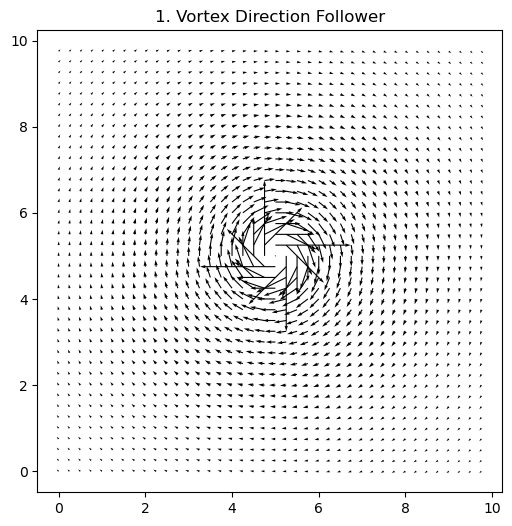

In [ ]:
# 9. Execute the simulations
# I am not sure why I chose these 4 simulations, and not all of them.
# I'll make sure all of them work at some point.

# Vortex Direction Follower
execute_simulation(vortex_direction_follower, '1. Vortex Direction Follower')

# Vortex Direction Source
execute_simulation(vortex_direction_source, '2. Vortex Direction Source')

# Vortex Magnitude Follower
execute_simulation(vortex_magnitude_follower, '3. Vortex Magnitude Follower')

# Vortex Magnitude Source
execute_simulation(vortex_magnitude_source, '4. Vortex Magnitude Source')

## Ye Old Control Primitives

In [ ]:
# # 7. Control Primitives

# # There has to be a way to pass less information to the control primitives.
# # Yes, I figured it out. I only need to feed it cluster.
# # In return, I need to ask these to only give me the newest cluster centre location.

# def max_flow_finder(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):
# #def max_flow_finder(cluster)
#     if np.sign(Ny)>0:
#         pos1[1] += robot_step_size
#         pos2[1] += robot_step_size
#         pos3[1] += robot_step_size
#     else:
#         pos1[1] -= robot_step_size
#         pos2[1] -= robot_step_size
#         pos3[1] -= robot_step_size
#     return pos1, pos2, pos3
    
# def spring_finder(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):
# #def spring_finder(cluster)    
#     angle = np.arctan2(Ny,Nx) #- np.pi/2
    
#     pos1[0] += robot_step_size*np.cos(angle)
#     pos1[1] += robot_step_size*np.sin(angle)
#     pos2[0] += robot_step_size*np.cos(angle)
#     pos2[1] += robot_step_size*np.sin(angle)
#     pos3[0] += robot_step_size*np.cos(angle)
#     pos3[1] += robot_step_size*np.sin(angle)
#     return pos1, pos2, pos3

# def fast_flow_aligned(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):
# # def fast_flow_aligned(cluster)
#     if np.sign(Ny)>0 and np.sign(Ny)>0:
#         pos1[1] += robot_step_size
#         pos2[1] += robot_step_size
#         pos3[1] += robot_step_size
#     elif np.sign(Ny)<0 and np.sign(Ny)<0:
#         pos1[1] -= robot_step_size
#         pos2[1] -= robot_step_size
#         pos3[1] -= robot_step_size
#     return pos1, pos2, pos3

# def stagnation_finder(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):
# #def stagnation_finder(cluster)    
#     global flaggs
    
#     angle = np.arctan2(Ny,Nx)
#     readings = [position_readings(pos[0], pos[1]) for pos in [pos1, pos2, pos3]]
#     composites = [composite_vector(u, v) for u, v in readings]

#     if (angle >0.2 ) or flaggs:     
#         #print()
#         composites = [(10 - comp[0], comp[1]) for comp in composites]
#         slope_x = (composites[1][0] - composites[0][0])/ robot_2_offset[0]
#         slope_y = (composites[2][0] - composites[0][0]) / robot_3_offset[1]
#         angle = np.arctan2(slope_y,slope_x) + np.pi/2
        
#         pos1[0] += robot_step_size*np.cos(angle)
#         pos1[1] += robot_step_size*np.sin(angle)
#         pos2[0] += robot_step_size*np.cos(angle)
#         pos2[1] += robot_step_size*np.sin(angle)
#         pos3[0] += robot_step_size*np.cos(angle)
#         pos3[1] += robot_step_size*np.sin(angle)
#         flaggs = True    
#     else:
#         angle -= np.pi/2
#         pos1[0] += robot_step_size*np.cos(angle)
#         pos1[1] += robot_step_size*np.sin(angle)
#         pos2[0] += robot_step_size*np.cos(angle)
#         pos2[1] += robot_step_size*np.sin(angle)
#         pos3[0] += robot_step_size*np.cos(angle)
#         pos3[1] += robot_step_size*np.sin(angle)
#     return pos1, pos2, pos3


# def cluster_reshape1(robot_1_start, robot_offset, x_source, y_source):
# #def cluster_reshape1(cluster)
# # I don't think this one actually works. These moves only dictate what the centroid should do.
#     pos1 = robot_1_start
#     [u1, v1] = position_readings(pos1[0],pos1[1])
#     pos2 = [pos1[0] + robot_offset, pos1[1] + robot_offset]
#     [u2, v2] = position_readings(pos2[0],pos2[1])
#     pos3 = [pos2[0] + robot_offset, pos2[1] + robot_offset]
#     [u3, v3] = position_readings(pos3[0],pos3[1])

#     [mag1, angle1] = composite_vector(u1,v1)
#     [mag2, angle2] = composite_vector(u2,v2)
#     [mag3, angle3] = composite_vector(u3,v3)

#     angle = (angle1+angle2+angle3)/3 +np.pi/2

#     pos1 = robot_1_start
#     pos2 = [pos1[0] + robot_offset*np.cos(angle),pos1[1] + robot_offset*np.sin(angle)]
#     pos3 = [pos2[0] + robot_offset*np.cos(angle),pos2[1] + robot_offset*np.sin(angle)]

#     return pos1, pos2, pos3, angle

# def separatrix_finder(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
# #def separatrix_finder(cluster)     # Computing Direction of the Bifurcation Line
    
#     angle = (composites[0][1] + composites[1][1] + composites[2][1]) / 3 +np.pi
  
#     # Moving 1 unit in Direction of Source

#     pos1[0] += step_size*np.cos(angle)
#     pos1[1] += step_size*np.sin(angle)
#     pos2[0] += step_size*np.cos(angle)
#     pos2[1] += step_size*np.sin(angle)
#     pos3[0] += step_size*np.cos(angle)
#     pos3[1] += step_size*np.sin(angle)
    
#     return pos1, pos2, pos3

# def separatrix_rider(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
# #def separatrix_rider(cluster)     # Computing Direction of the Bifurcation Line
    
#     angle = np.arctan2(Ny,Nx)
#     # Moving 1 unit in Direction of Source

#     pos1[0] += step_size*np.cos(angle)
#     pos1[1] += step_size*np.sin(angle)
#     pos2[0] += step_size*np.cos(angle)
#     pos2[1] += step_size*np.sin(angle)
#     pos3[0] += step_size*np.cos(angle)
#     pos3[1] += step_size*np.sin(angle)
    
#     return pos1, pos2, pos3

# def vortex_direction_follower(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
# # def vortex_direction_follower(cluster)    
#     angle = (composites[0][1] + composites[1][1] + composites[2][1]) / 3
    
 
#     pos1[0] += step_size*np.cos(angle)
#     pos1[1] += step_size*np.sin(angle)
#     pos2[0] += step_size*np.cos(angle)
#     pos2[1] += step_size*np.sin(angle)
#     pos3[0] += step_size*np.cos(angle)
#     pos3[1] += step_size*np.sin(angle)
    
   
#     return pos1, pos2, pos3

# def vortex_direction_source(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
# #def vortex_direction_source(cluster)
#     # Finding Average Direction
#     # Can Be done with 1 robot
    
#     angle = (composites[0][1] + composites[1][1] + composites[2][1]) / 3 - np.pi/2
    
#     pos1[0] += step_size*np.cos(angle)
#     pos1[1] += step_size*np.sin(angle)
#     pos2[0] += step_size*np.cos(angle)
#     pos2[1] += step_size*np.sin(angle)
#     pos3[0] += step_size*np.cos(angle)
#     pos3[1] += step_size*np.sin(angle)
    
#     return pos1, pos2, pos3

# def vortex_magnitude_follower(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
# #def vortex_magnitude_follower(cluster)     # Finding Average Direction
#     # Can Be done with 1 robot
    
#     angle = np.arctan2(Ny, Nx) + np.pi
    
#     pos1[0] += step_size*np.cos(angle)
#     pos1[1] += step_size*np.sin(angle)
#     pos2[0] += step_size*np.cos(angle)
#     pos2[1] += step_size*np.sin(angle)
#     pos3[0] += step_size*np.cos(angle)
#     pos3[1] += step_size*np.sin(angle)
    
#     return pos1, pos2, pos3

# def vortex_magnitude_source(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
# #def vortex_magnitude_source(cluster)
    
#     angle = np.arctan2(Ny, Nx) + np.pi/2
    
 
#     # Moving 1 unit in Direction of Source

#     pos1[0] += step_size*np.cos(angle)
#     pos1[1] += step_size*np.sin(angle)
#     pos2[0] += step_size*np.cos(angle)
#     pos2[1] += step_size*np.sin(angle)
#     pos3[0] += step_size*np.cos(angle)
#     pos3[1] += step_size*np.sin(angle)
    
#     return pos1, pos2, pos3

# def source_locator(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
# #def source_locator(cluster)    
#     x, y = symbols('x y')

#     # Form equations of lines from angles and positions, angle is with respect to upward direction
#     eq1 = Eq((y - pos1[1]) - np.tan(angle1)*(x - pos1[0]), 0)
#     eq2 = Eq((y - pos2[1]) - np.tan(angle2)*(x - pos2[0]), 0)
#     eq3 = Eq((y - pos3[1]) - np.tan(angle3)*(x - pos3[0]), 0)

#     solution12 = solve((eq1,eq2), (x, y))
#     solution23 = solve((eq2,eq3), (x, y))
#     solution13 = solve((eq1,eq3), (x, y))

#     # Average of intersection points
#     avg_x = (solution12[x] + solution23[x] + solution13[x]) / 3
#     avg_y = (solution12[y] + solution23[y] + solution13[y]) / 3
#     avg_x = float(avg_x.evalf())
#     avg_y = float(avg_y.evalf())
    
#     source_location = [avg_x, avg_y]

#     return source_location